##Problem Statement -

Linear regression to predict the salary:
Using Simple Linear Regression model, predict the salary of employed professionals based on their years of experience. Use the following dataset.

The dataset contains two columns namely: “YearsExperience” and “Salary”. In this case the model will be using the YearsExperience to predict the Salary. Hence, YearsExperience is the independent variable and Salary is the dependent variable.

#Understanding the dataset-


* The **input** (independent) variable is **YearsExperience**, which represents the employee's years of work experience.
* The **output** (target/dependent) variable is **Salary**, which the Linear Regression model predicts based on YearsExperience



In [ ]:
#Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [ ]:
#Loading the dataset
df = pd.read_csv('/content/Salary_Data.csv')

In [ ]:
#Displaying the First 5 Rows for Verification
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


##EDA Process

In [ ]:
df.shape

(30, 2)

The dataset contains 30 samples and 2 variables, which will be used to build a Simple Linear Regression model.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


The dataset contains two numerical columns with no null values, so no data type conversion or missing value treatment is required.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsExperience,30.0,5.313333,2.837888,1.1,3.20,4.7,7.70,10.5
Salary,30.0,76003.000000,27414.429785,37731.0,56720.75,65237.0,100544.75,122391.0


The dataset has a mean experience of 5.31 years and a mean salary of 76,003. The standard deviations indicate sufficient variation in both variables, which is beneficial for training a predictive model.

In [ ]:
# To find columns where all values are unique
unique_value_cols = [col for col in df.columns if df[col].nunique() == len(df)]

print("Columns containing unique values are:", unique_value_cols)

Columns containing unique values are: ['Salary']


 Although the Salary column contains all unique values, it is retained because it is the target (dependent) variable that the model is trained to predict.

In [ ]:
#Checking null values
df.isnull().sum()

,0
YearsExperience,0
Salary,0


The dataset has no missing values in either the YearsExperience or Salary column, ensuring that no missing value treatment is required & it is ready for further analysis and model building.

In [ ]:
# Checking the total number of duplicate rows
print("Total duplicate rows:", int(df.duplicated().sum()))

Total duplicate rows: 0


The duplicate check confirms that the dataset has zero duplicate rows, so no duplicate removal is required, ensuring data quality and preventing bias during model training.

**Note** - The dataset contains only ***numerical*** columns; therefore, splitting it into numerical and categorical columns is unnecessary, as both variables can be directly used for analysis and model building.

In [ ]:
# Detecting outliers in each numerical column using the IQR (Interquartile Range) method
num=['YearsExperience','Salary']
for col in num:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
  print(f'Column Name: {col}')
  print(f'Number of Outliers found : {len(outliers)}')


Column Name: YearsExperience
Number of Outliers found : 0
Column Name: Salary
Number of Outliers found : 0


The outlier analysis confirms that neither YearsExperience nor Salary contains extreme values outside the acceptable range. Hence, the dataset does not require any outlier handling.

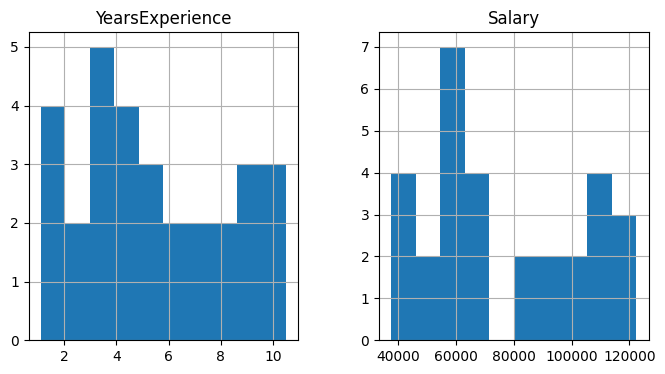

In [ ]:
## Performing univariate analysis by plotting histograms for all numerical columns
df.hist(figsize=(8,4))
plt.show()

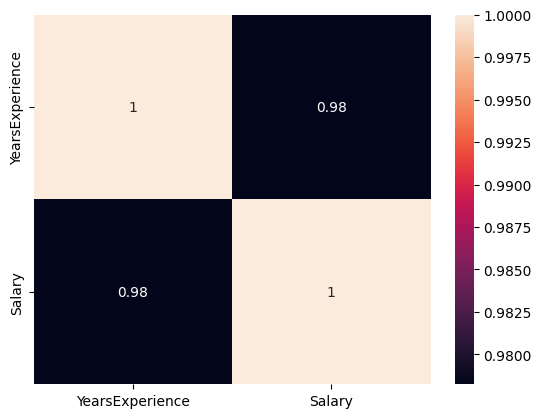

In [ ]:
# Performing bivariate analysis by visualizing the correlation between numerical features using a heatmap
sns.heatmap(df.corr(), annot=True)
plt.show()

The correlation coefficient of 0.98 suggests an almost perfect positive linear relationship between the independent variable (YearsExperience) and the dependent variable (Salary). This confirms that YearsExperience is a strong predictor of Salary.

##ML Model Building

In [ ]:
# Separating the independent (input) and dependent (target) variables
x = df.iloc[:,[0]]
y = df.iloc[:,1]

In [ ]:
x.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [ ]:
y.head()

,Salary
0,39343
1,46205
2,37731
3,43525
4,39891


In [ ]:
# Splitting the dataset into training and testing sets for model training and evaluation
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
# Creating and training the Linear Regression model using the training dataset
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Predicting the target values for the test dataset using the trained Linear Regression model
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [ ]:
# Evaluating the performance of the Linear Regression model using regression evaluation metrics.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)

Mean Squared Error: 49830096.85590839
Root Mean Squared Error: 7059.04362190151
R-squared: 0.9024461774180497
Mean Absolute Error: 6286.453830757749


Mean Squared Error (MSE): The average squared difference between the actual and predicted salary is 49,830,096.86, indicating the overall prediction error in squared salary units.

Root Mean Squared Error (RMSE): On average, the model's salary predictions differ from the actual salary by approximately ₹7,059.

R-squared (R² Score): The model explains approximately 90.24% of the variation in salary based on years of experience, indicating a strong linear relationship.

Mean Absolute Error (MAE): On average, the predicted salary differs from the actual salary by approximately ₹6,286.

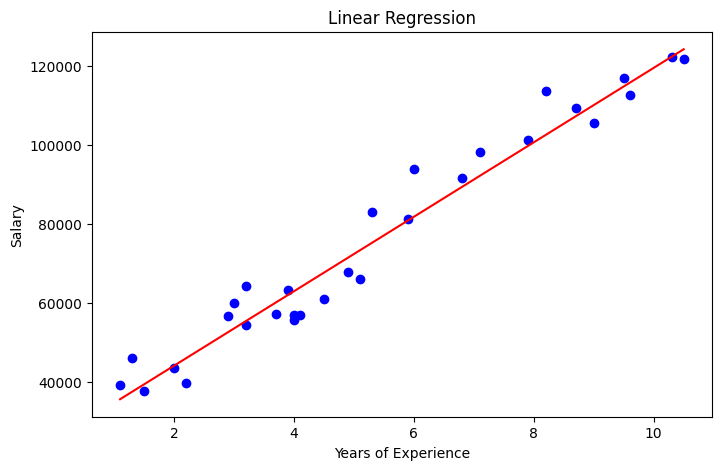

In [ ]:
#Plotting the regression line
plt.figure(figsize=(8,5))
plt.scatter(x, y, color="blue")
plt.plot(x, model.predict(x), color="red")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.show()

In [22]:
# Predicting the salary of a new employee based on the entered years of experience
yoe = int(input('Enter years of experience: '))
pred_output=model.predict([[yoe]])
print(f'Predicted Salary for {yoe} years of expreience is {pred_output[0]:.4f}')


Enter years of experience: 8
Predicted Salary for 8 years of expreience is 100712.1056
